In [56]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS,
                         poly,
                         sklearn_sm,
                         summarize)
from sklearn.model_selection import (cross_validate,
                                     KFold)
from matplotlib.pyplot import subplots


8. We will now perform cross-validation on a simulated data set.

(a) Generate a simulated data set as follows:

`rng = np.random.default_rng(1)`

`x = rng.normal(size=100)`

`y = x- 2 * x**2 + rng.normal(size=100)`

In this data set, what is n and what is p? Write out the model
used to generate the data in equation form

In [15]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x- 2 * x**2 + rng.normal(size=100)

(b) Create a scatterplot of X against Y . Comment on what you find

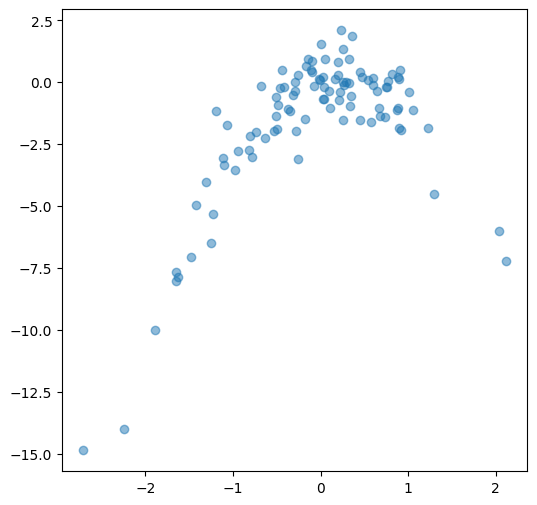

In [16]:
ax = subplots(figsize=(6,6))[1]
ax.scatter(x,y, alpha=0.5)

Uma curva em formato de "U" invertido, formato de uma expressão quadrática

(c) Set a random seed, and then compute the LOOCV errors that
result from fitting the following four models using least squares:

`i. Y = β0+β1X +ϵ`

`ii. Y = β0 +β1X +β2X2 +ϵ`

`iii. Y = β0 +β1X +β2X2 +β3X3 +ϵ`

`iv. Y = β0 +β1X +β2X2 +β3X3 +β4X4 +ϵ`

Note you may find it helpful to use the data.frame() function
to create a single data set containing both X and Y .

In [51]:
dataframe = pd.DataFrame({'x':x, 'y':y})
def cv_dataframe_graupolinominal(dataframe, cv_divisoes=None, graus=1, random_seed=42):
    cv_divisoes = cv_divisoes or dataframe.shape[0]
    cv = KFold(n_splits=cv_divisoes,
            shuffle=True,
            random_state=random_seed)
    modelo = sklearn_sm(sm.OLS)
    cv_erros = []
    for g in range(1,(graus + 1)):
        X = MS([poly('x', g)]).fit_transform(dataframe)
        m_cv = cross_validate(estimator=modelo,
                    X=X,
                    y=dataframe['y'],
                    cv=cv)
        cv_erros.append(np.mean(m_cv['test_score']))

    return cv_erros
r_1 = cv_dataframe_graupolinominal(dataframe=dataframe, graus=4, random_seed=0)
r_1

[np.float64(6.633029839181981),
 np.float64(1.1229368563419677),
 np.float64(1.3017965489359014),
 np.float64(1.3323942694179707)]

(d) Repeat (c) using another random seed, and report your results.
Are your results the same as what you got in (c)? Why?

In [53]:
r_2 = cv_dataframe_graupolinominal(dataframe=dataframe, graus=4, random_seed=42)
r_2 

[np.float64(6.633029839181981),
 np.float64(1.1229368563419677),
 np.float64(1.301796548935902),
 np.float64(1.3323942694179707)]

Os resultados foram iguais, como esperado, pois o LOOCV não se aplicada a aleatoriedade, todas as observações em algum momento viram o único registro de validação.

(e) Which of the models in (c) had the smallest LOOCV error? Is
this what you expected? Explain your answer.

O modelo quadrático foi o melhor, pois a natureza dos dados é um problema quadrático.

(f) Comment on the statistical significance of the coefficient esti
mates that results from fitting each of the models in (c) using
least squares. Do these results agree with the conclusions drawn
based on the cross-validation results?

In [63]:
for g in range(1,5):
    X = MS([poly('x', g)]).fit_transform(dataframe)
    print(f'\n*************** Modelo de {g}º grau ***************')
    print(summarize(sm.OLS(dataframe['y'], X).fit()))
    
    


*************** Modelo de 1º grau ***************
                      coef  std err      t  P>|t|
intercept          -1.6085    0.246 -6.543    0.0
poly(x, degree=1)  16.6000    2.458  6.752    0.0

*************** Modelo de 2º grau ***************
                         coef  std err       t  P>|t|
intercept             -1.6085    0.101 -15.974    0.0
poly(x, degree=2)[0]  16.6000    1.007  16.486    0.0
poly(x, degree=2)[1] -22.2244    1.007 -22.072    0.0

*************** Modelo de 3º grau ***************
                         coef  std err       t  P>|t|
intercept             -1.6085    0.101 -15.986  0.000
poly(x, degree=3)[0]  16.6000    1.006  16.499  0.000
poly(x, degree=3)[1] -22.2244    1.006 -22.089  0.000
poly(x, degree=3)[2]  -1.0768    1.006  -1.070  0.287

*************** Modelo de 4º grau ***************
                         coef  std err       t  P>|t|
intercept             -1.6085    0.098 -16.343  0.000
poly(x, degree=4)[0]  16.6000    0.984  16.867  0.00

O modelo quadrático mostra que ambos preditores tem impactos relevantes para a explicação dos dados, o primeiro modelo que não possui o termo ao quadrado tem um erro maior, pois faltam dados para que o modelo consiga explicar os dados de 'Y', fazendo com que ele tenha um viés alto. Os de 3º e 4º grau tem complexidades desnecessárias, porque possuem preditores que não tem relevância para explicar os dados de 'Y', tentam explicar o ruído tentando se adaptar as variações do erro natural do sistema, causando um overfitting. Essas conclusões vão ao encontro dos resultados com o LOOCV obtido em exercícios anteriores.